# **Depression Prediction** | 2025
---

# **I. Data Understanding**

# ***A. Penjabaran Studi Kasus***

Membangun model klasifikasi **Decision Tree** dari nol (scratch) menggunakan Python dasar untuk memprediksi apakah seorang mahasiswa mengalami Depression (Yes/No) berdasarkan faktor-faktor seperti tekanan akademik, kepuasan belajar, durasi tidur, kebiasaan makan, riwayat keluarga, dan lain-lain.

Yang harus dilakuin :
- Feature Creation > bikin fitur baru yaitu; stress index ((academic pressure + financial stress) / 2), dan lifestyle score (study satisfaction - encoded dietary habits)

# ***B. Import Libraries***

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import tkinter as tkinter

# ***C. Import Dataset***

In [3]:
dataset = pd.read_csv('Depression Student Dataset.csv')
dataset

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
497,Male,26,5.0,2.0,More than 8 hours,Unhealthy,No,8,3,No,Yes
498,Male,24,2.0,1.0,Less than 5 hours,Unhealthy,Yes,8,5,No,Yes
499,Female,23,3.0,5.0,5-6 hours,Healthy,No,1,5,Yes,No
500,Male,33,4.0,4.0,More than 8 hours,Healthy,No,8,1,Yes,No


# **II. Data Preparation**

# ***A. Exploratory Data Analysis***

#### 1. Inspeksi Daftar Variabel

In [4]:
dataset.columns

Index(['Gender', 'Age', 'Academic Pressure', 'Study Satisfaction',
       'Sleep Duration', 'Dietary Habits',
       'Have you ever had suicidal thoughts ?', 'Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='str')

Pengertian masing-masing variabel :
1. Gender = jenis kelamin pelajar
2. Age = umur pelajar
3. Academic Pressure = seberapa besar sekolah/pembelajaran membuat mereka tertekan 
4. Study Satisfaction = kepuasan mereka saat belajar
5. Sleep Duration = durasi mereka tidur
6. Dietary Habits = kebiasaan makan mereka
7. Have you ever had suicidal thoughts ? = apakah mereka pernah berpikiran untuk bunuh diri
8. Study Hours = seberapa lama mereka belajar di satu hari
9. Financial Stress = tingkat stress terkait kondisi keuangan mereka
10. Family History of Mental Illness = apakah ada anggota keluarga yang pernah terkena penyakit mental sebelumnya
11. Depression = target

#### 2. Inspeksi Informasi Ringkas

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    str    
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    str    
 5   Dietary Habits                         502 non-null    str    
 6   Have you ever had suicidal thoughts ?  502 non-null    str    
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    str    
 10  Depression                             502 non-null    str    
dtypes: float64(2), in

**Belum ditambah fitur barunya yg bawah**

In [6]:
discrete_feature = ['Age', 'Study Hours', 'Financial Stress']
conti_feature = ['Academic Pressure', 'Study Satisfaction']
nominal_feature = ['Sleep Duration', 'Dietary Habits']
ordinal_feature = ['Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
all_feature = ['Gender', 'Age', 'Academic Pressure', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Study Hours', 'Financial Stress', 'Family History of Mental Illness']

#### 3. Inspeksi Statistik Deskriptif

In [7]:
dataset.describe()

,Age,Academic Pressure,Study Satisfaction,Study Hours,Financial Stress
count,502.000000,502.000000,502.000000,502.000000,502.000000
mean,26.241036,3.003984,3.075697,6.404382,2.928287
std,4.896501,1.390007,1.373490,3.742434,1.425053
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,22.000000,2.000000,2.000000,3.000000,2.000000
50%,26.500000,3.000000,3.000000,7.000000,3.000000
75%,30.000000,4.000000,4.000000,10.000000,4.000000
max,34.000000,5.000000,5.000000,12.000000,5.000000


#### 4. Inspeksi Data NaN

In [8]:
dataset.isna().sum()

Gender                                   0
Age                                      0
Academic Pressure                        0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Study Hours                              0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

#### 5. Inspeksi Data Duplicated

In [9]:
dataset.duplicated().sum()

np.int64(0)

#### 6. Encoded

In [10]:
dataset['Sleep Duration'].unique()

<StringArray>
['7-8 hours', '5-6 hours', 'More than 8 hours', 'Less than 5 hours']
Length: 4, dtype: str

In [11]:
dataset['Dietary Habits'].unique()

<StringArray>
['Moderate', 'Healthy', 'Unhealthy']
Length: 3, dtype: str

In [12]:
dataset = dataset.drop_duplicates()
map_gender = {"Male" : 0, "Female" : 1}
map_yesno = {"Yes" : 0, "No" : 1}
map_duration = {"Less than 5 hours": 0, "5-6 hours": 1, "7-8 hours": 2, "More than 8 hours": 3}
map_habits = {"Unhealthy" : 0, "Moderate" : 1, "Healthy" : 2}
map_target = {"Yes" : 1, "No" : 0}

dataset['Gender'] = dataset['Gender'].map(map_gender)
dataset[ordinal_feature] = dataset[ordinal_feature].replace(map_yesno)
dataset['Sleep Duration'] = dataset['Sleep Duration'].map(map_duration)
dataset['Dietary Habits'] = dataset['Dietary Habits'].map(map_habits)
dataset['Depression'] = dataset['Depression'].map(map_target)

#### 7. Univariate Analysis

*a. Inspeksi Distribusi Kelas Target*

In [13]:
target_count = dataset['Depression'].value_counts()
target_count

Depression
1    252
0    250
Name: count, dtype: int64

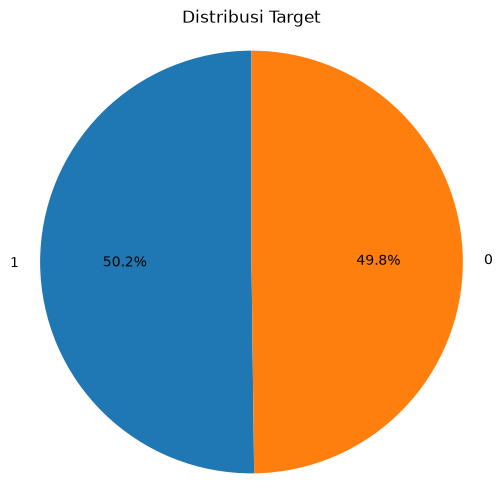

In [14]:
plt.figure(figsize=(6,6))
plt.pie(target_count, labels=target_count.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Target")
plt.axis('equal')
plt.show()

*b. Inspeksi Distribusi Kelas Fitur*

In [15]:
def check_value_simple(cols, top_n=2):
    for col in cols:
        print(f"Kolom: {col}")
        print(dataset[col].value_counts().sort_values(ascending=False).head(top_n))
        print("\n")

check_value_simple(all_feature, top_n=2)

Kolom: Gender
Gender
0    267
1    235
Name: count, dtype: int64


Kolom: Age
Age
28    39
20    37
Name: count, dtype: int64


Kolom: Academic Pressure
Academic Pressure
3.0    125
1.0     99
Name: count, dtype: int64


Kolom: Study Satisfaction
Study Satisfaction
4.0    116
3.0    103
Name: count, dtype: int64


Kolom: Sleep Duration
Sleep Duration
2    128
3    128
Name: count, dtype: int64


Kolom: Dietary Habits
Dietary Habits
1    172
0    169
Name: count, dtype: int64


Kolom: Have you ever had suicidal thoughts ?
Have you ever had suicidal thoughts ?
0    260
1    242
Name: count, dtype: int64


Kolom: Study Hours
Study Hours
10    53
12    46
Name: count, dtype: int64


Kolom: Financial Stress
Financial Stress
1    110
2    102
Name: count, dtype: int64


Kolom: Family History of Mental Illness
Family History of Mental Illness
1    265
0    237
Name: count, dtype: int64




#### 8. Bivariate Analysis

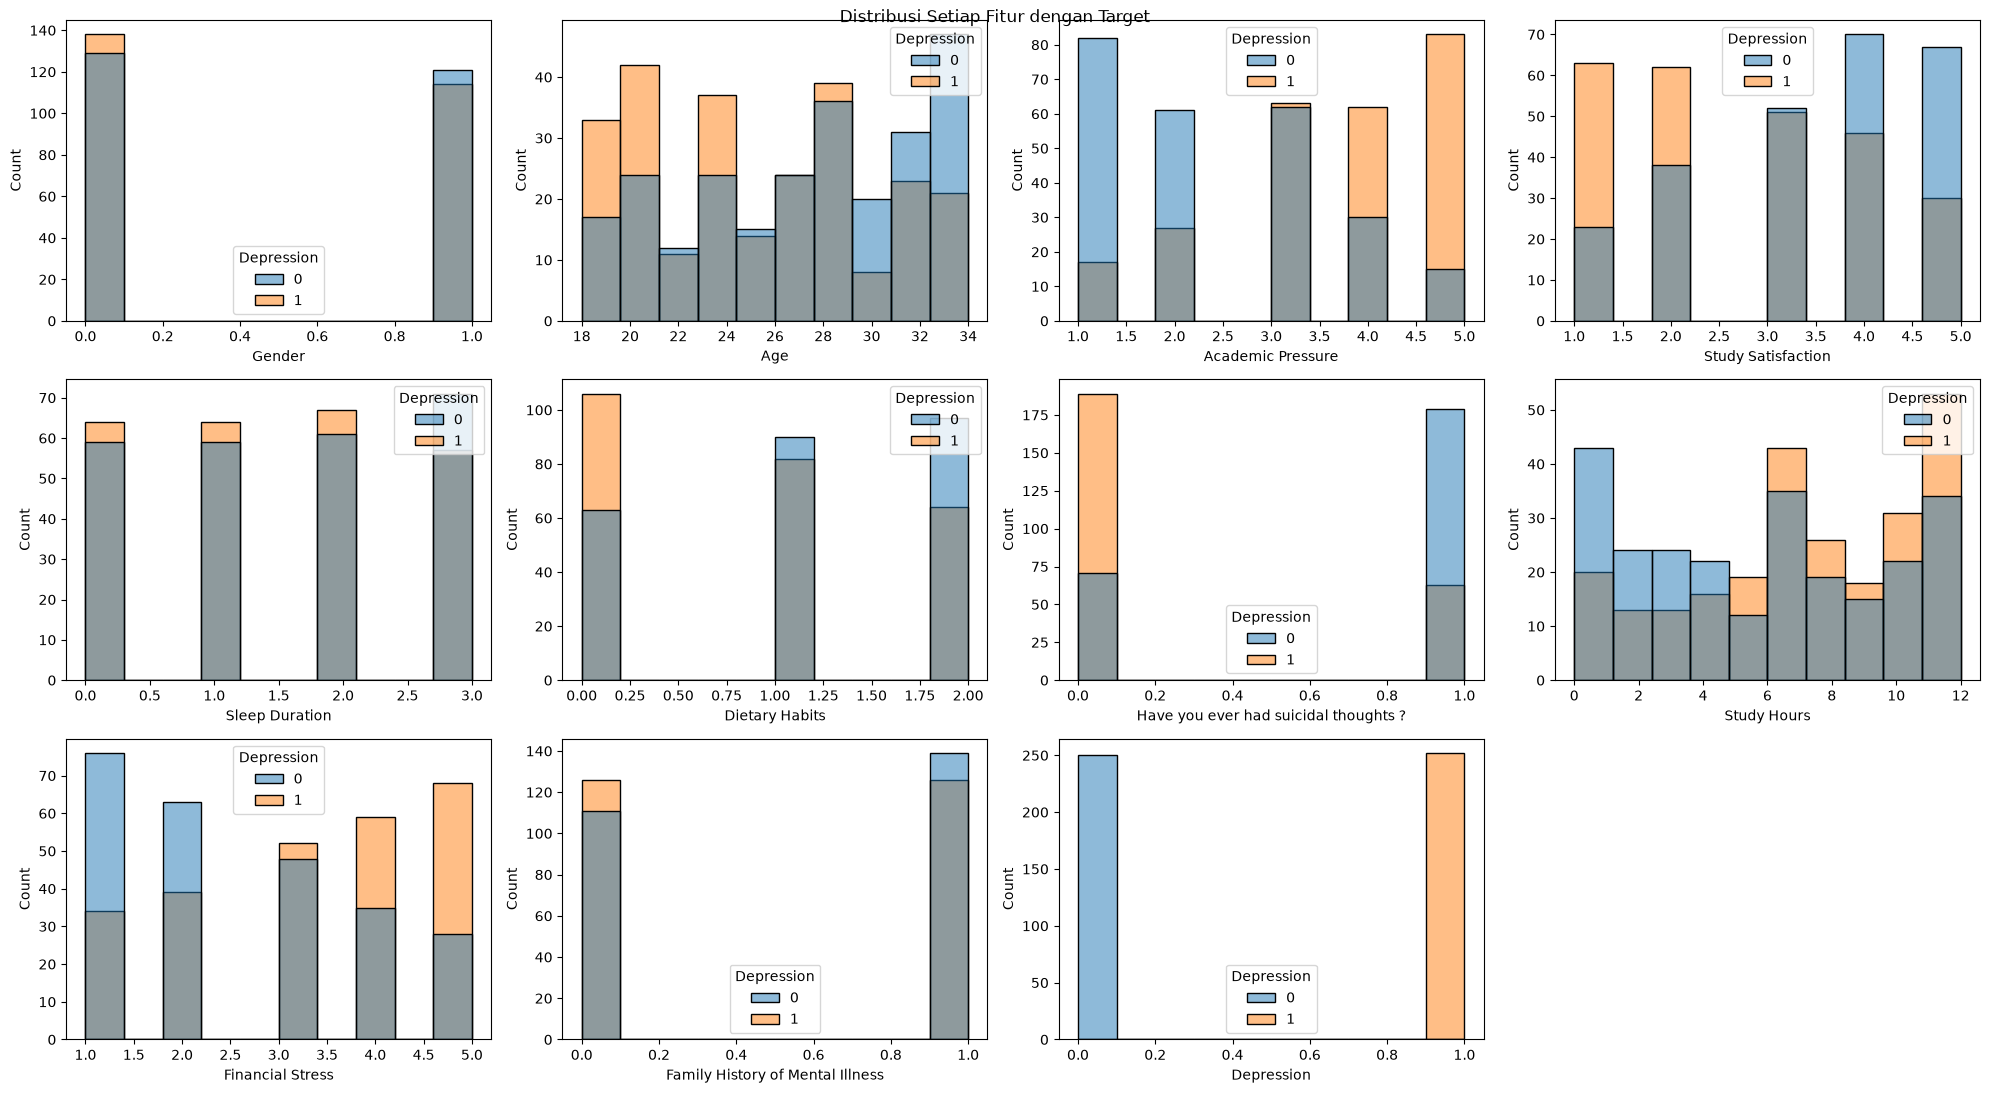

In [16]:
plt.figure(figsize=(20, 18))
for i, col in enumerate(dataset):
    plt.subplot(5, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset["Depression"])

plt.suptitle("Distribusi Setiap Fitur dengan Target")
plt.tight_layout()
plt.show()

#### 9. Multivariate Analysis

*a. Distribusi Variabel Numerik antara Target*

In [17]:
numeric_cols = ['Age', 'Academic Pressure', 'Study Satisfaction', 'Study Hours', 'Financial Stress']

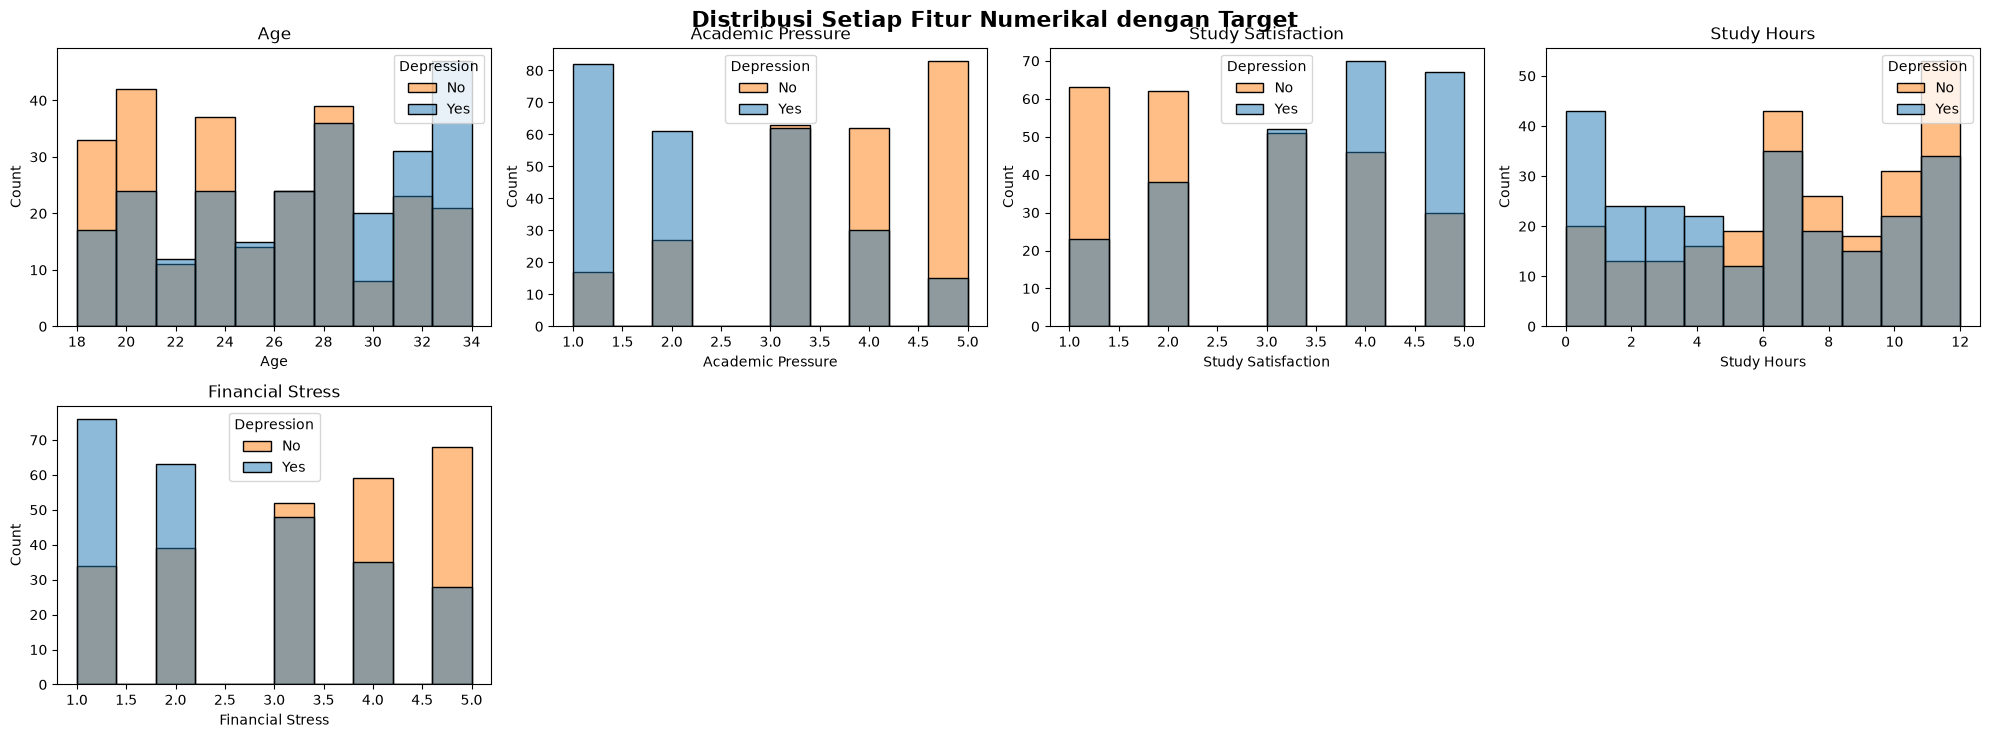

In [18]:
plt.figure(figsize=(20, 18))

for i, col in enumerate(numeric_cols):
    plt.subplot(5, 4, i+1) 
    sns.histplot(data=dataset, x=col, hue='Depression', kde=False)
    plt.title(f'{col}')
    plt.legend(title='Depression', labels=['No', 'Yes'])  

plt.suptitle("Distribusi Setiap Fitur Numerikal dengan Target", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

*b. Distribusi Variabel Kategorikal antara Target*

In [19]:
categorical_cols = ['Gender', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

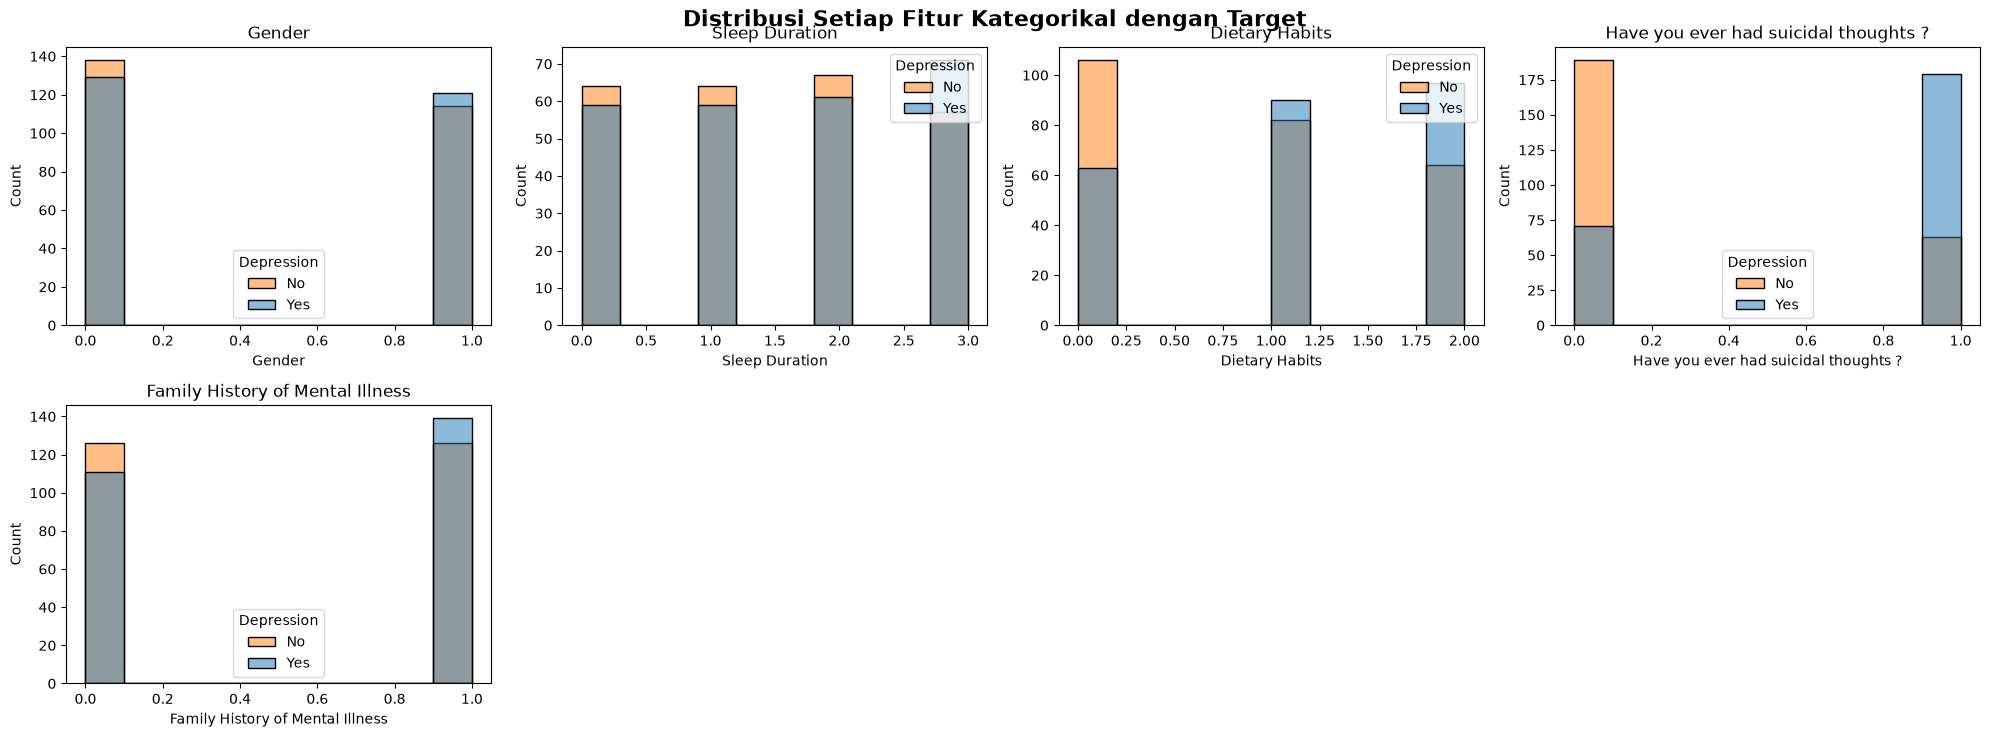

In [20]:
plt.figure(figsize=(20, 18))

for i, col in enumerate(categorical_cols):
    plt.subplot(5, 4, i+1) 
    sns.histplot(data=dataset, x=col, hue='Depression', kde=False)
    plt.title(f'{col}')
    plt.legend(title='Depression', labels=['No', 'Yes'])  

plt.suptitle("Distribusi Setiap Fitur Kategorikal dengan Target", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### 10. Feature Creation

*a. Stress Index*

In [21]:
dataset["Stress Index"] = (dataset["Academic Pressure"] + dataset["Financial Stress"]) / 2

In [22]:
dataset["Stress Index"].describe()

count    502.000000
mean       2.966135
std        0.996926
min        1.000000
25%        2.000000
50%        3.000000
75%        3.500000
max        5.000000
Name: Stress Index, dtype: float64

In [23]:
dataset["Stress Index"]

0      2.0
1      2.5
2      2.5
3      1.5
4      1.5
      ... 
497    4.0
498    3.5
499    4.0
500    2.5
501    3.5
Name: Stress Index, Length: 502, dtype: float64

*b. Lifestyle Score*

In [24]:
dataset["Lifestyle Score"] = dataset["Study Satisfaction"] - dataset["Dietary Habits"]

In [25]:
dataset["Lifestyle Score"].describe()

count    502.000000
mean       2.091633
std        1.579424
min       -1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        5.000000
Name: Lifestyle Score, dtype: float64

In [26]:
dataset["Lifestyle Score"]

0      3.0
1      3.0
2      3.0
3      4.0
4      3.0
      ... 
497    2.0
498    1.0
499    3.0
500    2.0
501    3.0
Name: Lifestyle Score, Length: 502, dtype: float64

*c. Distribusi Fitur Baru Berdasarkan Target*

In [27]:
new_feature = ['Stress Index', 'Lifestyle Score']

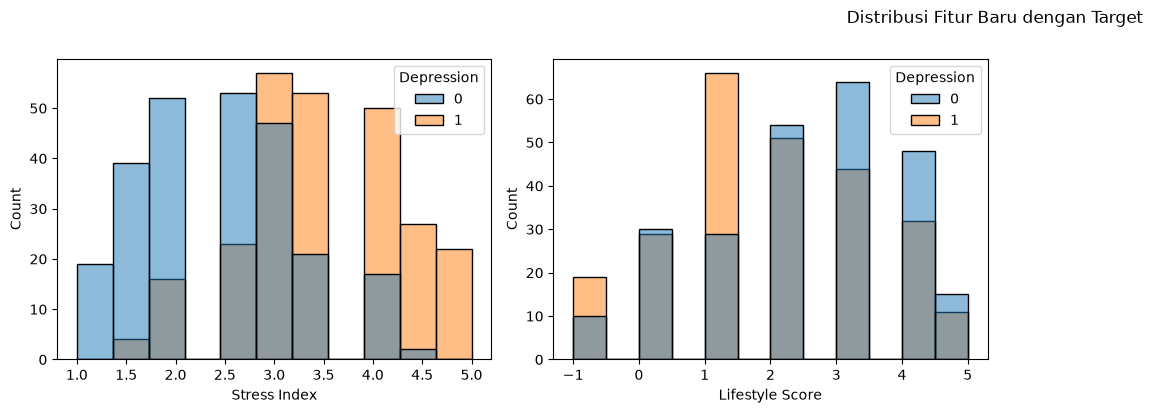

In [28]:
plt.figure(figsize=(20,18))
for i, col in enumerate(new_feature):
    plt.subplot(5,4,i+1)
    sns.histplot(x=dataset[col], hue=dataset['Depression'])

plt.suptitle("Distribusi Fitur Baru dengan Target", y=1.001)
plt.tight_layout()
plt.show()

In [29]:
new_all_feature = ['Gender', 'Age', 'Academic Pressure', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Stress Index', 'Lifestyle Score']

#### 11. Inspeksi Korelasi

*a. Mutual Information*

In [30]:
def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    return counts / counts.sum()

def calculate_entropy(x):
    probs = probability_distribution(x)
    return -np.sum(probs * np.log2(probs + 1e-10))

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unique_xy, counts_xy = np.unique(xy_pairs, return_counts=True)
    probs_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(probs_xy * np.log2(probs_xy + 1e-10))

    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x + entropy_y - entropy_xy

fitur = dataset[new_all_feature]
target = dataset["Depression"]

mi_scores = {col: mutual_information(fitur[col].values, target.values) for col in fitur.columns}
mi_df = pd.DataFrame(list(mi_scores.items()), columns=["Feature", "Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)

C:\Users\nizam\AppData\Local\Temp\ipykernel_15820\4128178644.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
C:\Users\nizam\AppData\Local\Temp\ipykernel_15820\4128178644.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


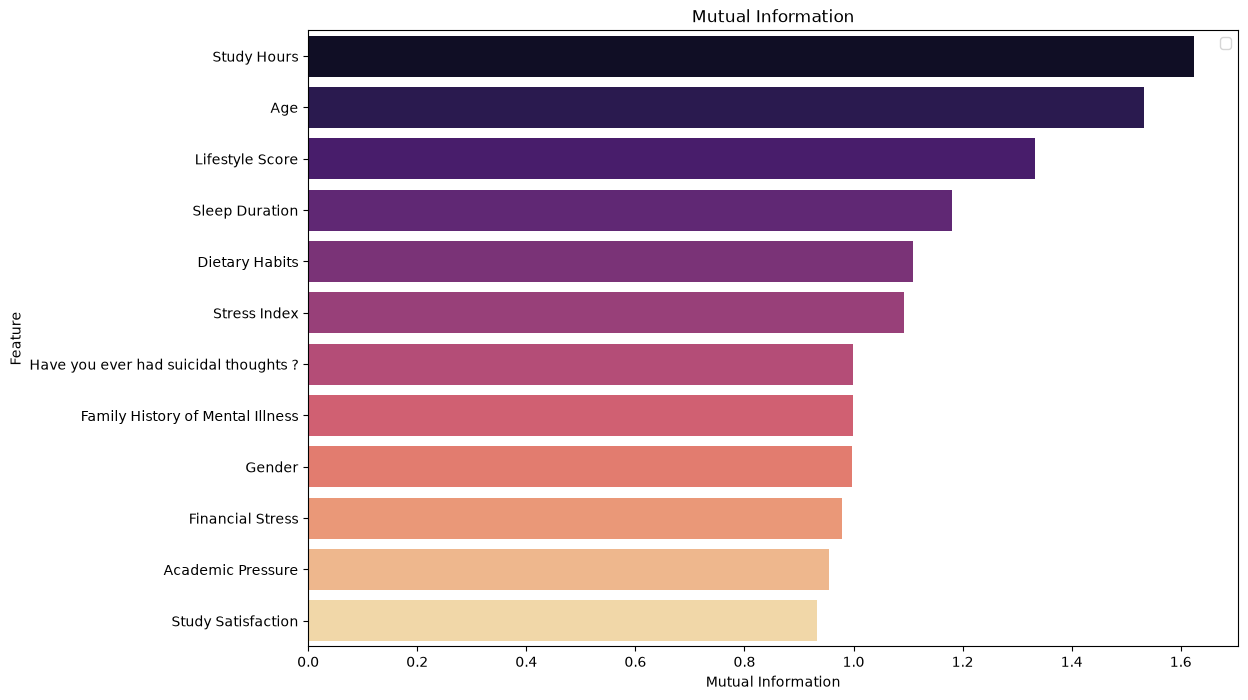

In [31]:
plt.figure(figsize=(12, 8))
sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Mutual Information")
plt.legend()
plt.show()

In [32]:
mi_df

,Feature,Mutual Information
7,Study Hours,1.624067
1,Age,1.531933
11,Lifestyle Score,1.333004
4,Sleep Duration,1.180630
5,Dietary Habits,1.109606
10,Stress Index,1.092026
6,Have you ever had suicidal thoughts ?,0.999244
9,Family History of Mental Illness,0.998387
0,Gender,0.997700
8,Financial Stress,0.979302


*b. Method Kendall* 

In [33]:
kendall_cols = new_all_feature + ['Depression']
data_for_kendall = dataset[kendall_cols].copy()

def kendall_tau_manual(x, y):
    n = len(x)
    concordant = 0
    discordant = 0
    
    for i in range(n):
        for j in range(i+1, n):
            diff_x = x[i] - x[j]
            diff_y = y[i] - y[j]
            
            if diff_x * diff_y > 0:
                concordant += 1  
            elif diff_x * diff_y < 0:
                discordant += 1  
    
    total_pairs = concordant + discordant
    if total_pairs == 0:
        return 0.0
    tau = (concordant - discordant) / total_pairs
    return tau

n_cols = len(kendall_cols)
kendall_matrix = np.zeros((n_cols, n_cols))

for i in range(n_cols):
    for j in range(n_cols):
        col_i = data_for_kendall.iloc[:, i].values
        col_j = data_for_kendall.iloc[:, j].values
        tau = kendall_tau_manual(col_i, col_j)
        kendall_matrix[i, j] = abs(tau) 
        
kendall_df = pd.DataFrame(kendall_matrix, index=kendall_cols, columns=kendall_cols)

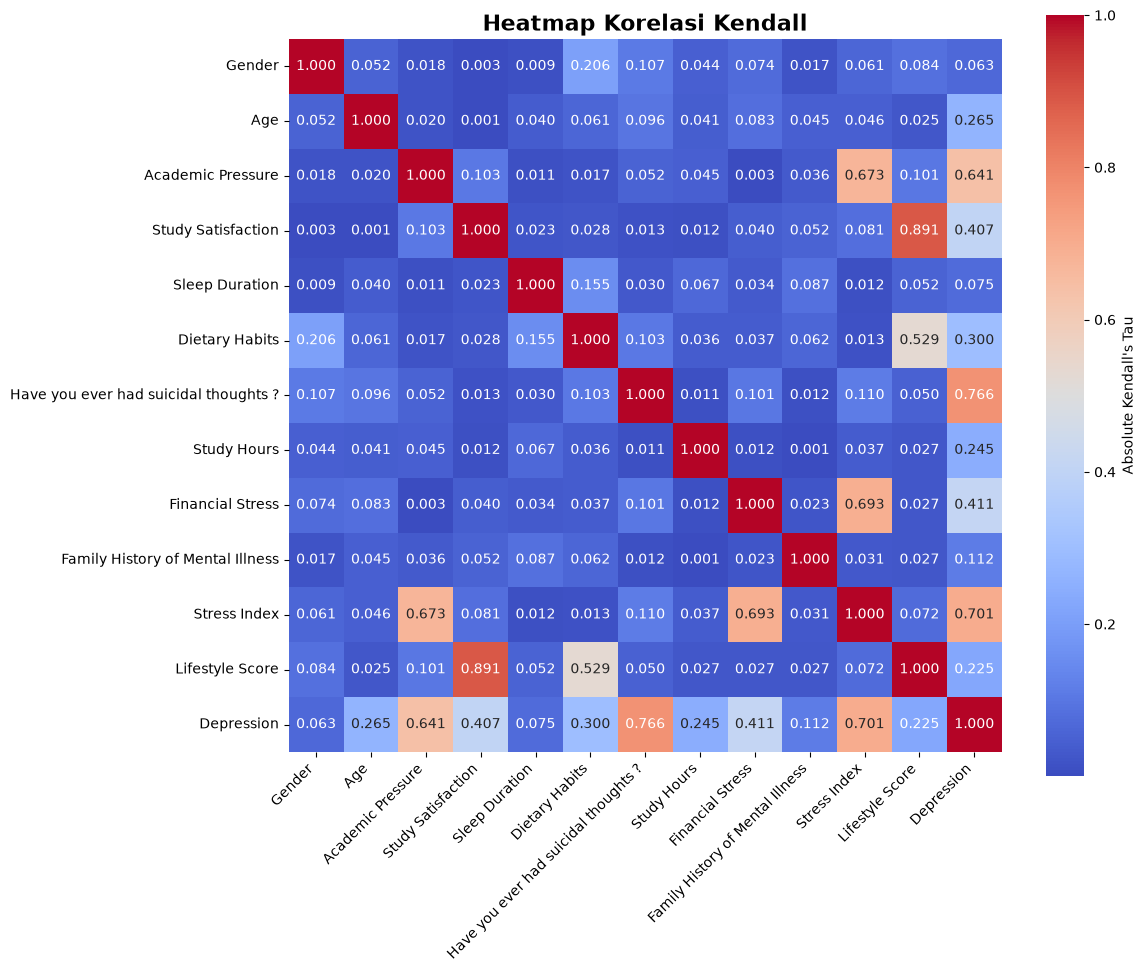

In [34]:
plt.figure(figsize=(12, 10))
sns.heatmap(kendall_df, annot=True, cmap='coolwarm', fmt='.3f', square=True, cbar_kws={'label': 'Absolute Kendall\'s Tau'})
plt.title("Heatmap Korelasi Kendall", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

*c. Method Chi Square*

In [35]:
def chi_square(data, col1, col2):
    observed = pd.crosstab(data[col1], data[col2])
    
    total = observed.values.sum()
    
    row_totals = observed.sum(axis=1).values.reshape(-1, 1)   # bentuk vertikal
    col_totals = observed.sum(axis=0).values.reshape(1, -1)   # bentuk horizontal
    expected = np.dot(row_totals, col_totals) / total
    
    chi2_stat = ((observed.values - expected) ** 2 / expected).sum()
    
    return chi2_stat  

chi_scores = []

for col in new_all_feature:
    chi = chi_square(dataset, col, 'Depression')
    chi_scores.append((col, chi))

chi_df = pd.DataFrame(chi_scores, columns=['Features', 'Chi Scores'])
chi_df = chi_df.sort_values(by="Chi Scores", ascending=False).reset_index(drop=True)

print("\n=== Chi-Square Scores ===")
chi_df


=== Chi-Square Scores ===


,Features,Chi Scores
0,Stress Index,152.988593
1,Academic Pressure,114.129083
2,Have you ever had suicidal thoughts ?,109.150916
3,Financial Stress,44.630489
4,Study Satisfaction,43.446001
5,Age,36.338636
6,Study Hours,26.843329
7,Lifestyle Score,24.817807
8,Dietary Habits,18.069215
9,Sleep Duration,2.211071


C:\Users\nizam\AppData\Local\Temp\ipykernel_15820\2717313639.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chi_df, y='Features', x='Chi Scores', palette='viridis')


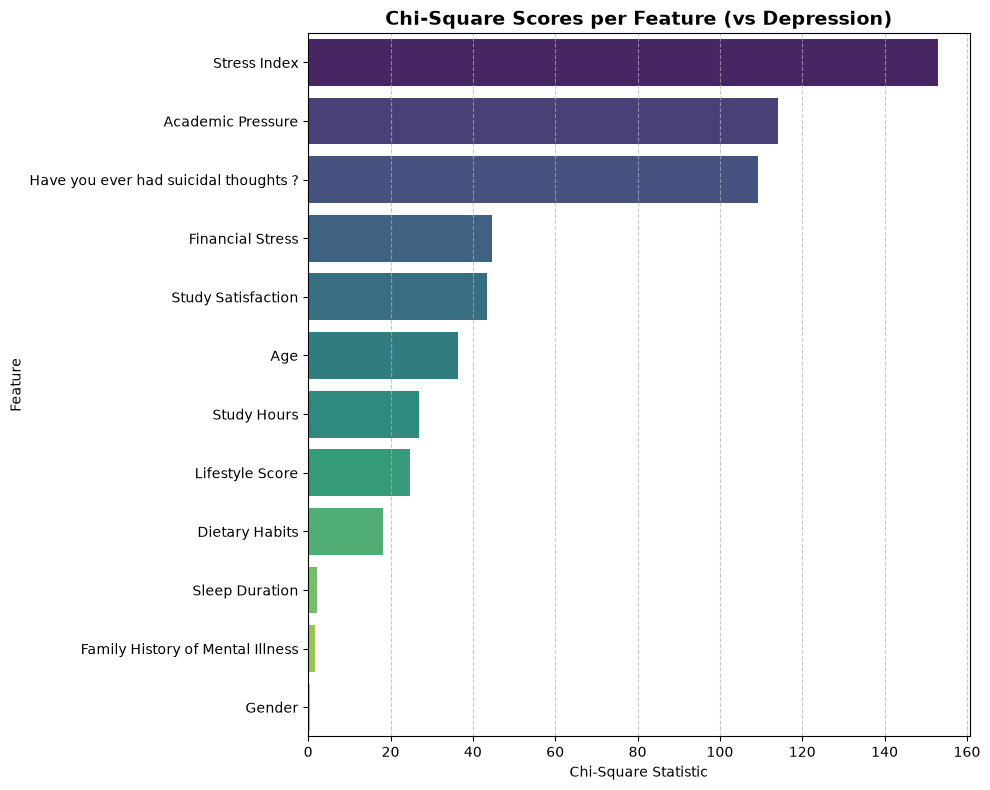

In [36]:
plt.figure(figsize=(10, 8))
sns.barplot(data=chi_df, y='Features', x='Chi Scores', palette='viridis')
plt.title("Chi-Square Scores per Feature (vs Depression)", fontsize=14, fontweight='bold')
plt.xlabel("Chi-Square Statistic")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 12. Inspeksi Outlier

<Axes: xlabel='Depression', ylabel='Study Hours'>

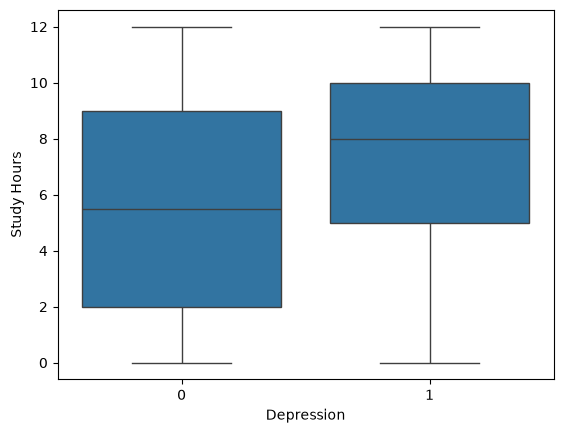

In [37]:
sns.boxplot(data=dataset, x="Depression", y="Study Hours")

# ***B. Feature Selection***

Menggunakan semua fitur

# ***C. Data Preprocessing***

Dataset sudah bersih, tidak ada data kotor, tidak ada outlier

# ***D. Splitting Dataset***

#### 1. Stratified Splitting

In [38]:
def stratified_split(dataset, target_column, training_size=0.8, random_state=42):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset[target_column].unique():
        class_data = dataset[dataset[target_column] == class_value]
        class_data = class_data.sample(frac=1, random_state=random_state)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_train, dataset_test = stratified_split(dataset, "Depression")

#### 2. Stratified K-Fold

In [39]:
def stratified_kfold(dataset, target_column, n_splits=5, random_state=42):
    np.random.seed(random_state)
    classes = dataset[target_column].unique()
    folds = [[] for _ in range(n_splits)]

    for cls in classes:
        class_data = dataset[dataset[target_column] == cls].copy()
        class_data = class_data.sample(frac=1, random_state=random_state).reset_index(drop=True)

        chuck_size = len(class_data) // n_splits
        remainder = len(class_data) % n_splits

        start_idx = 0
        for i in range(n_splits):
            end_idx = start_idx + chuck_size + (1 if i < remainder else 0)
            fold_data = class_data.iloc[start_idx:end_idx]
            folds[i].append(fold_data)
            start_idx = end_idx
    
    final_folds = []
    for i in range(n_splits):
        fold_df = pd.concat(folds[i], ignore_index=True)
        final_folds.append(fold_df)

    return final_folds

# **III. Modeling**

# ***A. Model Application***

In [40]:
class TreeEnsemble:
    def __init__(self, max_depth=12, min_samples_split=2, feature_names=new_all_feature, mode="single"):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.feature_names = feature_names
        self.mode = mode
        self.trees = None

    def most_common_value(self, arr):
        unique, counts = np.unique(arr, return_counts=True)
        return unique[np.argmax(counts)]

    def entropy(self, y):
        if len(y) == 0:
            return 0
        unique, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs + 1e-9))

    def information_gain(self, parent, left, right):
        if len(left) == 0 or len(right) == 0:
            return 0
        return self.entropy(parent) - (
            (len(left) / len(parent)) * self.entropy(left) +
            (len(right) / len(parent)) * self.entropy(right)
        )

    def _build_tree(self, X, y, depth=0):
        # Base case: stop if max depth, pure node, or too few samples
        if depth >= self.max_depth or len(np.unique(y)) <= 1 or len(y) < self.min_samples_split:
            return self.most_common_value(y)

        best_feature, best_split, best_gain = None, None, -1

        for feature in range(X.shape[1]):
            unique_values = np.unique(X[:, feature])
            if len(unique_values) == 1:
                continue

            # Generate midpoints between sorted unique values for better splits
            sorted_vals = np.sort(unique_values)
            if len(sorted_vals) > 1:
                thresholds = (sorted_vals[:-1] + sorted_vals[1:]) / 2
            else:
                thresholds = sorted_vals

            for value in thresholds:
                left_mask = X[:, feature] <= value
                right_mask = ~left_mask

                y_left = y[left_mask]
                y_right = y[right_mask]

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gain = self.information_gain(y, y_left, y_right)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_split = value

        if best_gain <= 0:  # no useful split found
            return self.most_common_value(y)

        left_mask = X[:, best_feature] <= best_split
        right_mask = ~left_mask

        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            "feature": best_feature,
            "split": best_split,
            "left": left_subtree,
            "right": right_subtree,
            "labels": y.tolist(),
            "most_common": self.most_common_value(y)
        }

    def fit(self, X, y):
        if self.mode == "single":
            self.trees = self._build_tree(X, y)
        else:
            raise NotImplementedError("Mode ensemble belum diaktifkan.")

    def _predict_sample(self, tree, sample):
        if not isinstance(tree, dict):
            return tree
        if sample[tree["feature"]] <= tree["split"]:
            return self._predict_sample(tree["left"], sample)
        else:
            return self._predict_sample(tree["right"], sample)

    def predict(self, X):
        return np.array([self._predict_sample(self.trees, sample) for sample in X])

    def print_tree(self, tree=None, depth=0):
        if tree is None:
            tree = self.trees
        if not isinstance(tree, dict):
            print("  " * depth + f"Leaf → Predict: {tree}")
            return
        feature_name = self.feature_names[tree['feature']] if self.feature_names else f"Feature_{tree['feature']}"
        print("  " * depth + f"Q: {feature_name} <= {tree['split']}?")
        print("  " * depth + "├─ True:")
        self.print_tree(tree['left'], depth + 1)
        print("  " * depth + "└─ False:")
        self.print_tree(tree['right'], depth + 1)

    def plot_tree(self, tree=None, x=0.5, y=1, dx=0.25, dy=0.15, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(20, 12))  # Diperkecil agar tidak error
            ax.set_title("Decision Tree Visualization", fontsize=20, fontweight='bold')
        ax.axis("off")
        if tree is None:
            tree = self.trees

        def _plot_node(ax, tree, x, y, x_offset, y_offset):
            if not isinstance(tree, dict):
                text = f"Predict: {tree}\n(Class)"
                ax.text(x, y, text, 
                        bbox=dict(facecolor="lightgreen", edgecolor='black', boxstyle='round,pad=0.5'), 
                        ha='center', va='center', fontsize=10, fontweight='bold')
                return

            feature_name = self.feature_names[tree["feature"]] if self.feature_names else f"F{tree['feature']}"
            labels = tree.get("labels", [])
            most_common = tree.get("most_common", "N/A")
            if len(labels) > 0:
                unique, counts = np.unique(labels, return_counts=True)
                label_info = "\n".join([f"{k}: {v}" for k, v in zip(unique, counts)])
            else:
                label_info = "No data"

            node_text = f"{feature_name} ≤ {tree['split']}\nSamples: {len(labels)}\n{label_info}\nMajority: {most_common}"
            ax.text(x, y, node_text,
                    bbox=dict(facecolor="lightblue", edgecolor='black', boxstyle='round,pad=0.5'),
                    ha='center', va='center', fontsize=9, wrap=True)

            x_left, x_right = x - x_offset, x + x_offset
            y_next = y - y_offset

            ax.plot([x, x_left], [y, y_next], 'k-', lw=1.5)
            ax.plot([x, x_right], [y, y_next], 'k-', lw=1.5)

            ax.text((x + x_left)/2 - 0.01, (y + y_next)/2, "True", color='green', fontsize=10, fontweight='bold', ha='right')
            ax.text((x + x_right)/2 + 0.01, (y + y_next)/2, "False", color='red', fontsize=10, fontweight='bold', ha='left')

            _plot_node(ax, tree['left'], x_left, y_next, x_offset / 2, y_offset)
            _plot_node(ax, tree['right'], x_right, y_next, x_offset / 2, y_offset)

        _plot_node(ax, tree, x, y, dx, dy)
        plt.tight_layout()

In [42]:

# 1. Define the missing function to calculate accuracy manually
def accuracy_score_manual(y_true, y_pred):
    """Menghitung akurasi dengan membandingkan nilai asli dan prediksi"""
    return np.mean(y_true == y_pred)

# 2. Cross-validation loop
folds = stratified_kfold(dataset, "Depression", n_splits=5, random_state=42)
accuracies = []

for i, fold in enumerate(folds):
    test_set = fold
    
    # Update: Menggunakan len(folds) agar dinamis jika n_splits diubah
    train_set = pd.concat([folds[j] for j in range(len(folds)) if j != i], ignore_index=True)

    X_train_fold = train_set[new_all_feature].values
    y_train_fold = train_set['Depression'].values
    X_test_fold = test_set[new_all_feature].values
    y_test_fold = test_set['Depression'].values

    # Inisialisasi dan latih model
    dt_fold = TreeEnsemble(max_depth=10, min_samples_split=5, feature_names=new_all_feature, mode="single")
    dt_fold.fit(X_train_fold, y_train_fold)
    
    # Prediksi
    y_pred_fold = dt_fold.predict(X_test_fold)

    # Hitung akurasi menggunakan fungsi manual yang sudah didefinisikan di atas
    acc_fold = accuracy_score_manual(y_test_fold, y_pred_fold)
    accuracies.append(acc_fold)
    
    print(f"Fold {i+1} Accuracy: {acc_fold:.4f}")

# Print hasil akhir
print(f"\nRata-rata Akurasi CV: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")

Fold 1 Accuracy: 0.7624
Fold 2 Accuracy: 0.8614
Fold 3 Accuracy: 0.8100
Fold 4 Accuracy: 0.8600
Fold 5 Accuracy: 0.8500

Rata-rata Akurasi CV: 0.8288 ± 0.0381


In [46]:
# 1. Siapkan 100% data (tidak dibagi menjadi fold lagi)
X_full = dataset[new_all_feature].values
y_full = dataset['Depression'].values

# 2. Buat model baru (dt) dan latih dengan seluruh data
dt = TreeEnsemble(max_depth=10, min_samples_split=5, feature_names=new_all_feature, mode="single")
dt.fit(X_full, y_full)

print("Model final telah dilatih dengan 100% data!")

# 3. Print tree dalam bentuk teks
print("\n--- Struktur Tree (Teks) ---")
dt.print_tree()

Model final telah dilatih dengan 100% data!

--- Struktur Tree (Teks) ---
Q: Stress Index <= 2.75?
├─ True:
  Q: Have you ever had suicidal thoughts ? <= 0.5?
  ├─ True:
    Q: Study Satisfaction <= 4.5?
    ├─ True:
      Q: Age <= 26.5?
      ├─ True:
        Q: Stress Index <= 1.75?
        ├─ True:
          Q: Study Hours <= 5.5?
          ├─ True:
            Leaf → Predict: 0
          └─ False:
            Leaf → Predict: 1
        └─ False:
          Q: Study Hours <= 4.0?
          ├─ True:
            Q: Dietary Habits <= 0.5?
            ├─ True:
              Leaf → Predict: 1
            └─ False:
              Leaf → Predict: 0
          └─ False:
            Leaf → Predict: 1
      └─ False:
        Q: Academic Pressure <= 1.5?
        ├─ True:
          Leaf → Predict: 0
        └─ False:
          Q: Study Hours <= 3.0?
          ├─ True:
            Leaf → Predict: 0
          └─ False:
            Q: Study Satisfaction <= 2.5?
            ├─ True:
              Leaf

# ***B. Visualisasi Model***

*a. Tree*

<Figure size 4000x2000 with 0 Axes>

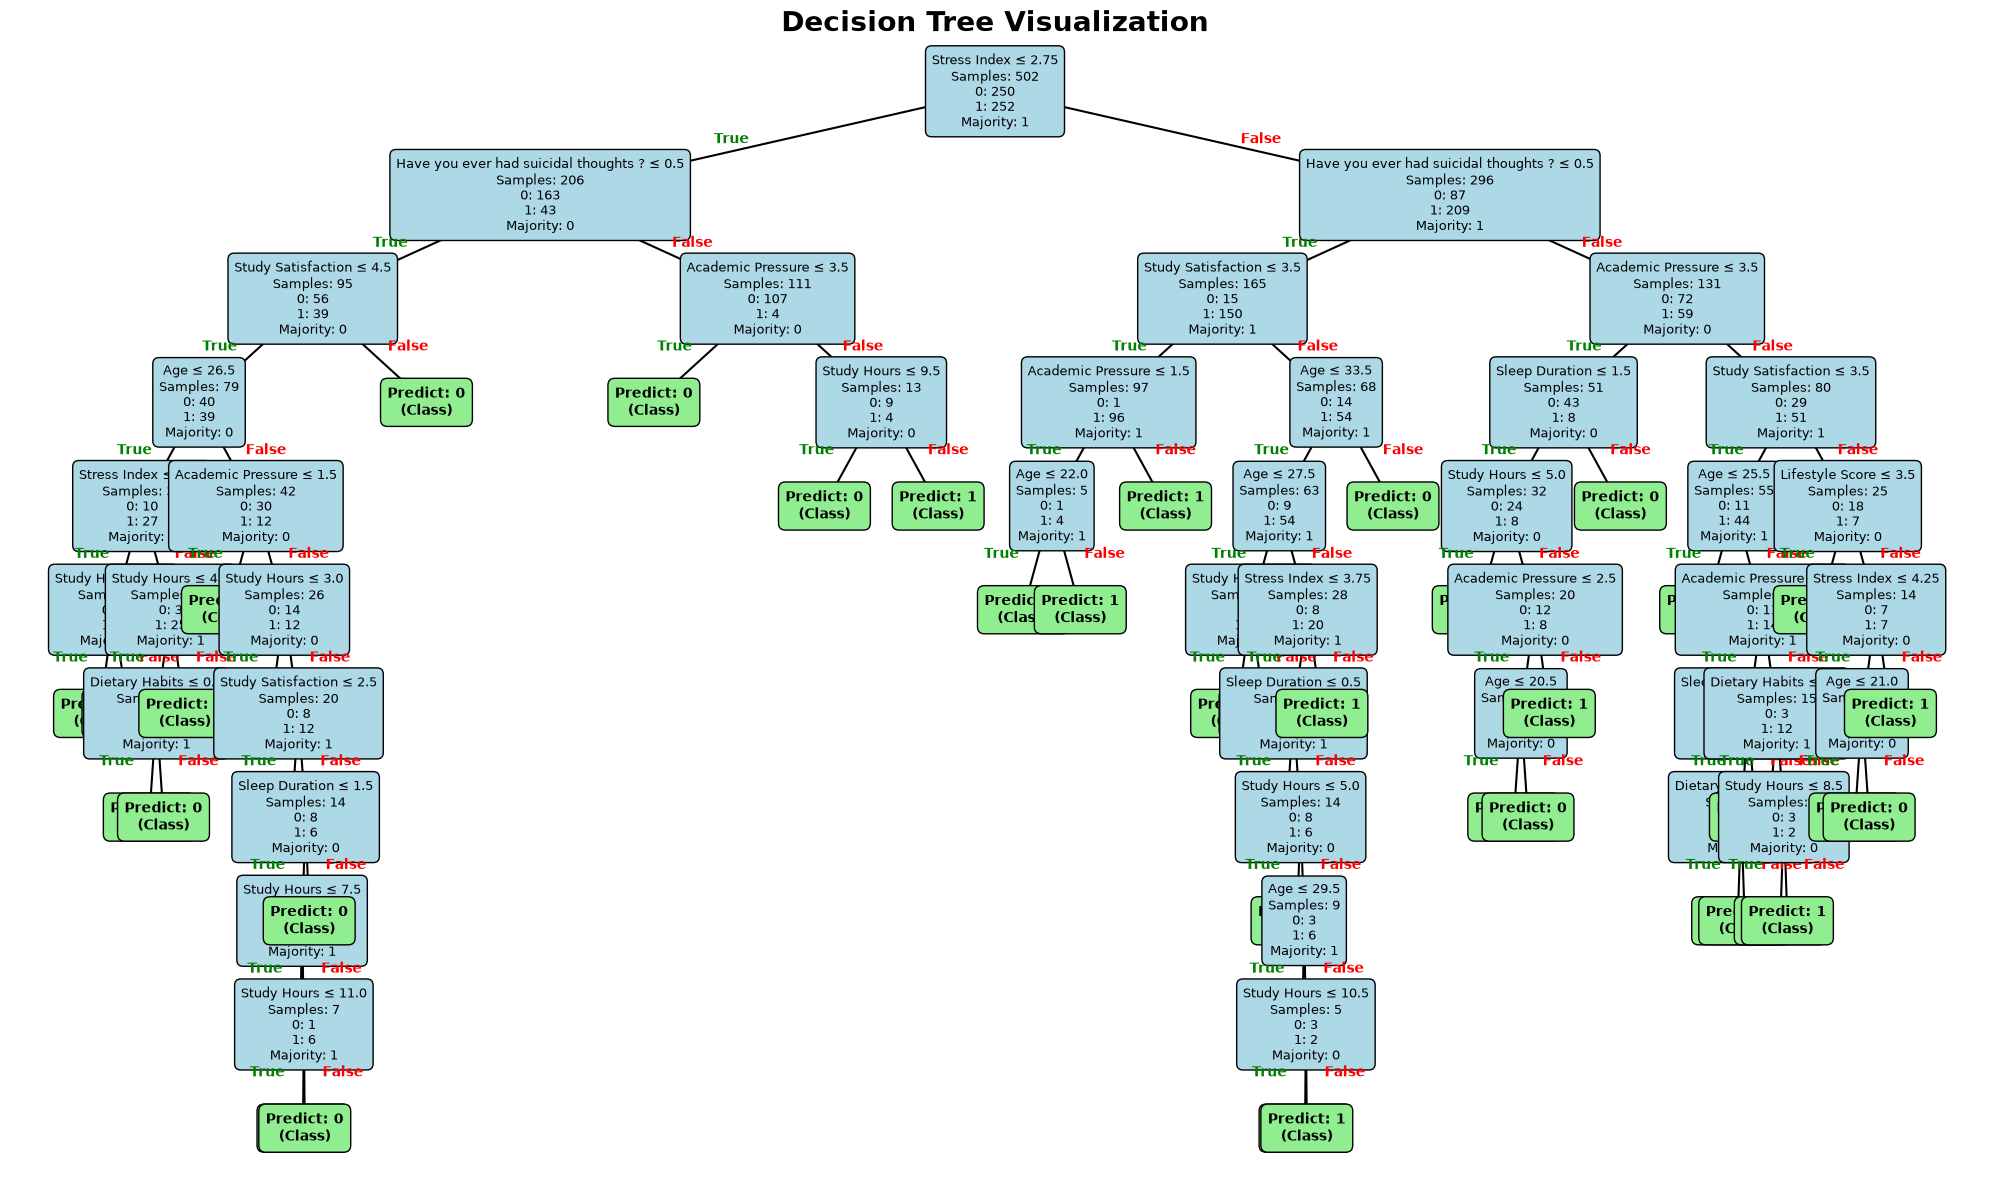

In [47]:
plt.figure(figsize=(40, 20))
dt.plot_tree()
plt.show()

*b. Distribusi Hasil Prediksi*

    1. Training Model

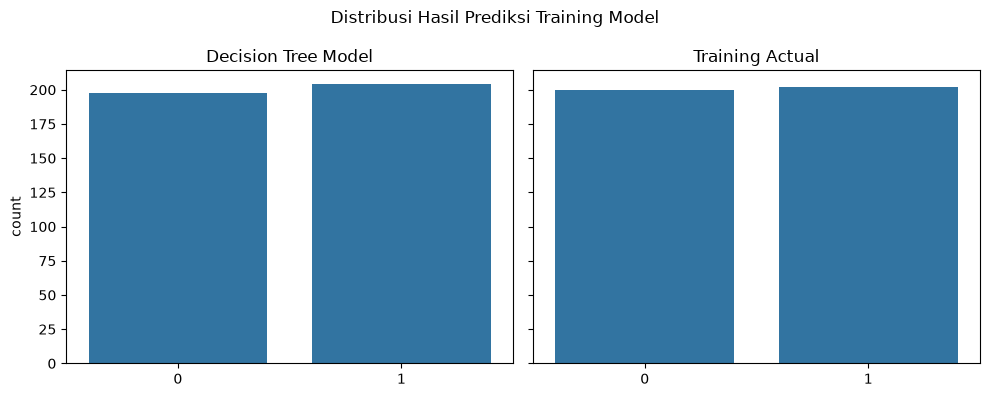

In [49]:
y_train_pred = dt.predict(X_train_fold)

data_train_pred = pd.DataFrame({
    "Decision Tree Model": y_train_pred,
    "Training Actual": y_train_fold
})

fig, axes = plt.subplots(1, data_train_pred.shape[1], figsize=(10, 4), sharey=True)

for ax, col in zip(axes, data_train_pred.columns):
    sns.countplot(x=data_train_pred[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

axes[0].set_ylabel("count")
fig.suptitle("Distribusi Hasil Prediksi Training Model")
fig.tight_layout()
plt.show()

    2. Testing Model

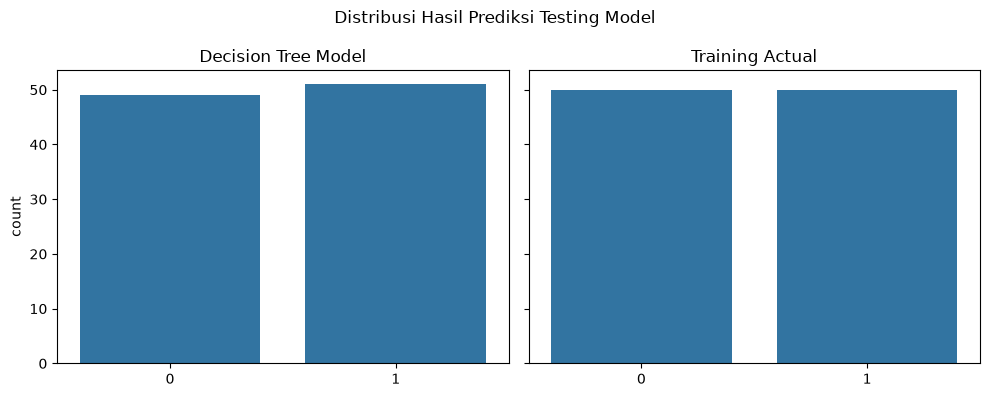

In [50]:
y_test_pred = dt.predict(X_test_fold)

data_test_pred = pd.DataFrame({
    "Decision Tree Model": y_test_pred,
    "Training Actual": y_test_fold
})

fig, axes = plt.subplots(1, data_test_pred.shape[1], figsize=(10, 4), sharey=True)

for ax, col in zip(axes, data_test_pred.columns):
    sns.countplot(x=data_test_pred[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

axes[0].set_ylabel("count")
fig.suptitle("Distribusi Hasil Prediksi Testing Model")
fig.tight_layout()
plt.show()

*c. Confusion Matrix*

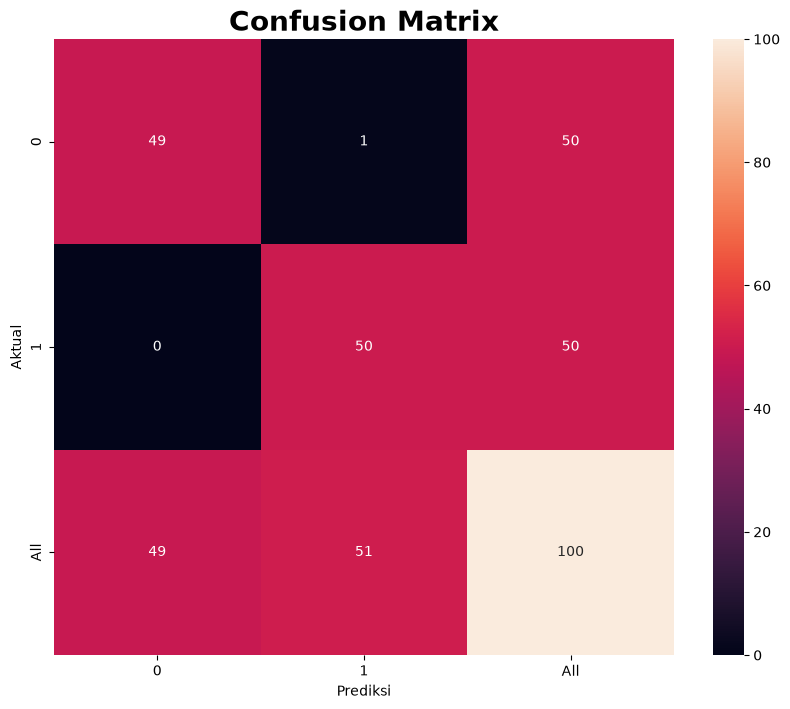

col_0,0,1,All
row_0,,,
0,49,1,50
1,0,50,50
All,49,51,100


In [52]:
data_confusion = pd.crosstab(y_test_fold, y_test_pred, margins=True)

plt.figure(figsize=(10,8))
plt.title("Confusion Matrix", size=20, weight='bold')

sns.heatmap(data_confusion, annot=True, fmt='.0f')

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

display(data_confusion)

# ***C. Evaluasi Model***

*a. Confusion Matrix*

In [53]:
def evaluation_metric(y_true, y_pred, average):
    accuracy_list, precision_list, recall_list, f1_list = [], [], [], []
    labels = np.unique(y_true)

    for label in labels:
        TP = np.sum((y_true == label) & (y_pred == label))
        FP = np.sum((y_true != label) & (y_pred == label))
        TN = np.sum((y_true != label) & (y_pred != label))
        FN = np.sum((y_true == label) & (y_pred != label))

        accuracy = (TP + TN) / (TP + TN + FP + FN) * 100 if (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if  (TP + FP)  != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

        accuracy_list.append(accuracy)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1_score)

    if average == 'macro':
        accuracy = np.mean(accuracy_list)
        precision = np.mean(precision_list)
        recall = np.mean(recall_list)
        f1_score = np.mean(f1_list)

    elif average == 'micro':
        TP = np.sum(y_true == y_pred)
        FP = np.sum((y_true != y_pred) & (y_pred != y_true))

        TN = np.sum(y_true == y_pred)
        FN = np.sum((y_true == y_pred) & (y_true != y_pred))

        accuracy = (TP + TN) /  (TP + TN + FP + FN) * 100 if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if  (TP + FP)  != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return accuracy, precision, recall, f1_score

In [55]:
accuracy_train, precision_train, recall_train, f1_score_train = evaluation_metric(y_train_fold ,y_train_pred, average='micro')
print(f"Akurasi Tree Train: {accuracy_train:.2f}")
print(f"Presisi Tree Train: {precision_train:.2f}")
print(f"Recall Tree Train: {recall_train:.2f}")
print(f"F1 Score Tree Train: {f1_score_train:.2f}")

Akurasi Tree Train: 99.25
Presisi Tree Train: 0.99
Recall Tree Train: 1.00
F1 Score Tree Train: 0.99


In [56]:
accuracy_test, precision_test, recall_test, f1_score_test = evaluation_metric(y_test_fold ,y_test_pred, average='micro')
print(f"Akurasi Tree Test: {accuracy_test:.2f}")
print(f"Presisi Tree Test: {precision_test:.2f}")
print(f"Recall Tree Test: {recall_test:.2f}")
print(f"F1 Score Tree Test: {f1_score_test:.2f}")

Akurasi Tree Test: 99.50
Presisi Tree Test: 0.99
Recall Tree Test: 1.00
F1 Score Tree Test: 0.99


*b. Bias and Variance Model*

In [57]:
bias = 100 - accuracy_test
variance = accuracy_train - accuracy_test
data = {
    'Metric' : ['Bias', 'Variance'],
    'Value' : [bias, variance]
}

data_eval = pd.DataFrame(data)

C:\Users\nizam\AppData\Local\Temp\ipykernel_15820\785001057.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_eval, x='Metric', y='Value', palette='coolwarm')


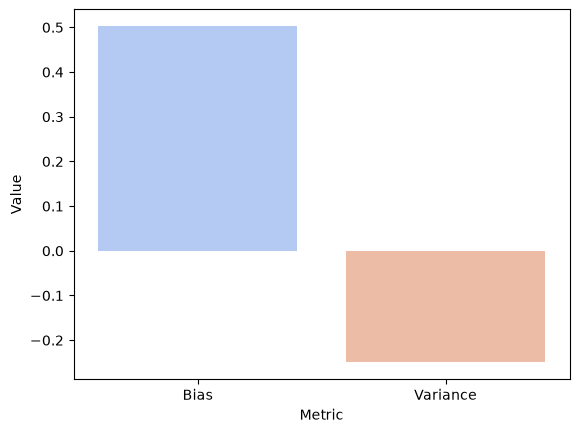

In [58]:
sns.barplot(data=data_eval, x='Metric', y='Value', palette='coolwarm')
plt.show()

*c. K-Fold Cross Validation*

In [59]:
folds = stratified_kfold(dataset, "Depression", n_splits=5, random_state=42)

for i, fold in enumerate(folds):
    print(f"Fold {i+1}: {len(fold)} samples")
    print(fold['Depression'].value_counts())
    print("-" * 30)

Fold 1: 101 samples
Depression
1    51
0    50
Name: count, dtype: int64
------------------------------
Fold 2: 101 samples
Depression
1    51
0    50
Name: count, dtype: int64
------------------------------
Fold 3: 100 samples
Depression
0    50
1    50
Name: count, dtype: int64
------------------------------
Fold 4: 100 samples
Depression
0    50
1    50
Name: count, dtype: int64
------------------------------
Fold 5: 100 samples
Depression
0    50
1    50
Name: count, dtype: int64
------------------------------


# **IV. GUI**

In [60]:
class DepressionApp:
    def __init__(self):
        self.root = tkinter.Tk()
        self.root.title("Depression Self-Test App")
        self.root.geometry("700x500")
        self.root.configure(bg="#f4f4f4")

        self.questions = [
            "Saya merasa sedih atau kosong hampir setiap hari.",
            "Saya kehilangan minat pada hal-hal yang dulu saya sukai.",
            "Saya merasa lelah hampir sepanjang waktu.",
            "Saya sulit tidur atau tidur terlalu banyak.",
            "Saya merasa tidak berharga atau bersalah berlebihan.",
            "Saya kesulitan fokus pada hal-hal sederhana.",
            "Saya kehilangan nafsu makan atau makan berlebihan.",
            "Saya sering berpikir hidup ini tidak ada artinya."
        ]
        self.answers = []
        self.current_index = 0

        self.build_intro()

        self.root.mainloop()

    def build_intro(self):
        self.clear_window()

        title = tkinter.Label(self.root, text="Tes Kesehatan Mental", font=("Arial", 20, "bold"), bg="#f4f4f4", fg="#333")
        title.pack(pady=40)

        desc = tkinter.Label(
            self.root,
            text="Jawab pertanyaan berikut untuk mengetahui tingkat stres atau depresi yang mungkin kamu rasakan.\n"
                 "Jawabanmu bersifat anonim dan tidak disimpan di mana pun.",
            font=("Arial", 12),
            bg="#f4f4f4",
            fg="#555"
        )
        desc.pack(pady=20)

        start_btn = tkinter.Button(
            self.root,
            text="Mulai Tes",
            font=("Arial", 14, "bold"),
            bg="#4CAF50",
            fg="white",
            padx=20,
            pady=10,
            command=self.start_test
        )
        start_btn.pack(pady=50)

    def start_test(self):
        self.answers = []
        self.current_index = 0
        self.show_question()

    def show_question(self):
        self.clear_window()
        q_text = self.questions[self.current_index]

        q_label = tkinter.Label(self.root, text=f"Pertanyaan {self.current_index + 1}/{len(self.questions)}", font=("Arial", 14, "bold"), bg="#f4f4f4")
        q_label.pack(pady=20)

        question_label = tkinter.Label(self.root, text=q_text, font=("Arial", 16), bg="#f4f4f4", wraplength=600, justify="center")
        question_label.pack(pady=40)

        frame = tkinter.Frame(self.root, bg="#f4f4f4")
        frame.pack()

        options = [("Tidak Pernah", 0), ("Kadang-kadang", 1), ("Sering", 2)]
        for text, value in options:
            btn = tkinter.Button(frame, text=text, font=("Arial", 13), width=15, bg="#2196F3", fg="white",
                                 command=lambda val=value: self.record_answer(val))
            btn.pack(side="left", padx=10, pady=10)

    def record_answer(self, value):
        self.answers.append(value)
        self.current_index += 1

        if self.current_index < len(self.questions):
            self.show_question()
        else:
            self.show_result()

    def show_result(self):
        self.clear_window()

        total_score = np.sum(self.answers)
        max_score = len(self.questions) * 2
        percentage = (total_score / max_score) * 100

        if percentage < 30:
            status = "Kamu tampak dalam kondisi emosional yang cukup stabil. Pertahankan keseimbangan hidupmu!"
            color = "#4CAF50"
        elif percentage < 60:
            status = "Kamu mungkin sedang mengalami stres ringan. Coba istirahat dan cari kegiatan yang menyenangkan."
            color = "#FFB300"
        else:
            status = "Tanda-tanda depresi terlihat cukup kuat. Tidak apa-apa untuk mencari bantuan profesional."
            color = "#E53935"

        result_label = tkinter.Label(
            self.root,
            text="HASIL TES",
            font=("Arial", 20, "bold"),
            bg="#f4f4f4",
            fg="#333"
        )
        result_label.pack(pady=20)

        score_label = tkinter.Label(
            self.root,
            text=f"Skor kamu: {total_score}/{max_score} ({percentage:.1f}%)",
            font=("Arial", 14),
            bg="#f4f4f4",
            fg=color
        )
        score_label.pack(pady=10)

        status_label = tkinter.Label(
            self.root,
            text=status,
            font=("Arial", 13),
            bg="#f4f4f4",
            wraplength=600,
            justify="center"
        )
        status_label.pack(pady=30)

        restart_btn = tkinter.Button(
            self.root,
            text="Ulangi Tes",
            font=("Arial", 13, "bold"),
            bg="#2196F3",
            fg="white",
            padx=20,
            pady=10,
            command=self.build_intro
        )
        restart_btn.pack(pady=20)

    def clear_window(self):
        for widget in self.root.winfo_children():
            widget.destroy()

if __name__ == "__main__":
    DepressionApp()
